<a href="https://colab.research.google.com/github/vinothkumard2006-ai/data-science/blob/main/Traffic_Signal_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Untitled spreadsheet.gsheet',
 'job survey.gsheet',
 'final_combined_enriched_v4.csv',
 'Colab Notebooks',
 'Medicinal plant dataset',
 'data_for_preprocessing.csv',
 'Traffic Sign Recognition for Autonomous Vehicle']

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/Traffic Sign Recognition for Autonomous Vehicle'))

['Test.csv', 'Meta.csv', 'Train.csv', 'Meta', 'Test', 'Train']


**Step 1**: Import Libraries

In [ ]:
!pip install tensorflow pandas numpy matplotlib opencv-python scikit-learn

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# set base path
base_path = "/content/drive/MyDrive/Traffic Sign Recognition for Autonomous Vehicle"

 Read CSV files

In [ ]:
Meta = pd.read_csv(base_path + "/Meta.csv")
Meta

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22
5,Meta/12.png,12,2,2,2.3
6,Meta/13.png,13,4,0,2.1
7,Meta/14.png,14,3,0,2.2
8,Meta/15.png,15,1,0,3.1
9,Meta/16.png,16,1,0,3.3


In [ ]:
Meta.columns

Index(['Path', 'ClassId', 'ShapeId', 'ColorId', 'SignId'], dtype='object')

In [ ]:
Meta.shape

(43, 5)

In [ ]:
Meta.isna().sum()

,0
Path,0
ClassId,0
ShapeId,0
ColorId,0
SignId,1


In [ ]:
Meta['SignId']=Meta['SignId'].fillna(0)

In [ ]:
Meta.dtypes

,0
Path,object
ClassId,int64
ShapeId,int64
ColorId,int64
SignId,object


In [ ]:
Meta['SignId'].unique()

array(['1.32', '3.29', '3.27', '1.22', '2.3', '2.1', '2.2', '3.1', '3.3',
       '3.21', '1.39', '1.2', '1.1', '1.3.2', '1.13', '1.5.2', '1.37',
       '1.24', '1.33', '1.34', 0, '1.36', '3.42', '4.2', '4.3', '4.1',
       '4.4', '4.5', '4.7', '4.8', '3.26', '3.28', '3.25'], dtype=object)

In [ ]:
Meta.duplicated().sum()

np.int64(0)

In [ ]:
Meta.nunique()

,0
Path,43
ClassId,43
ShapeId,5
ColorId,4
SignId,33


In [ ]:
Meta.shape

(43, 5)

Meta images for understand for every traffic Sign category

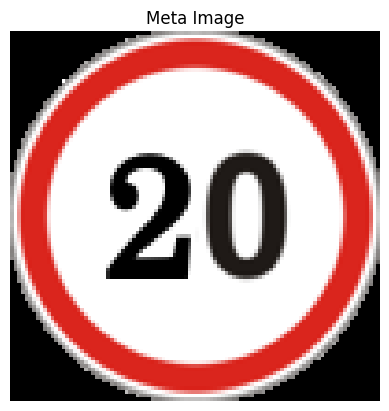

In [ ]:
img_path = base_path + "/Meta/0.png"
img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Meta Image")
plt.axis("off")
plt.show()

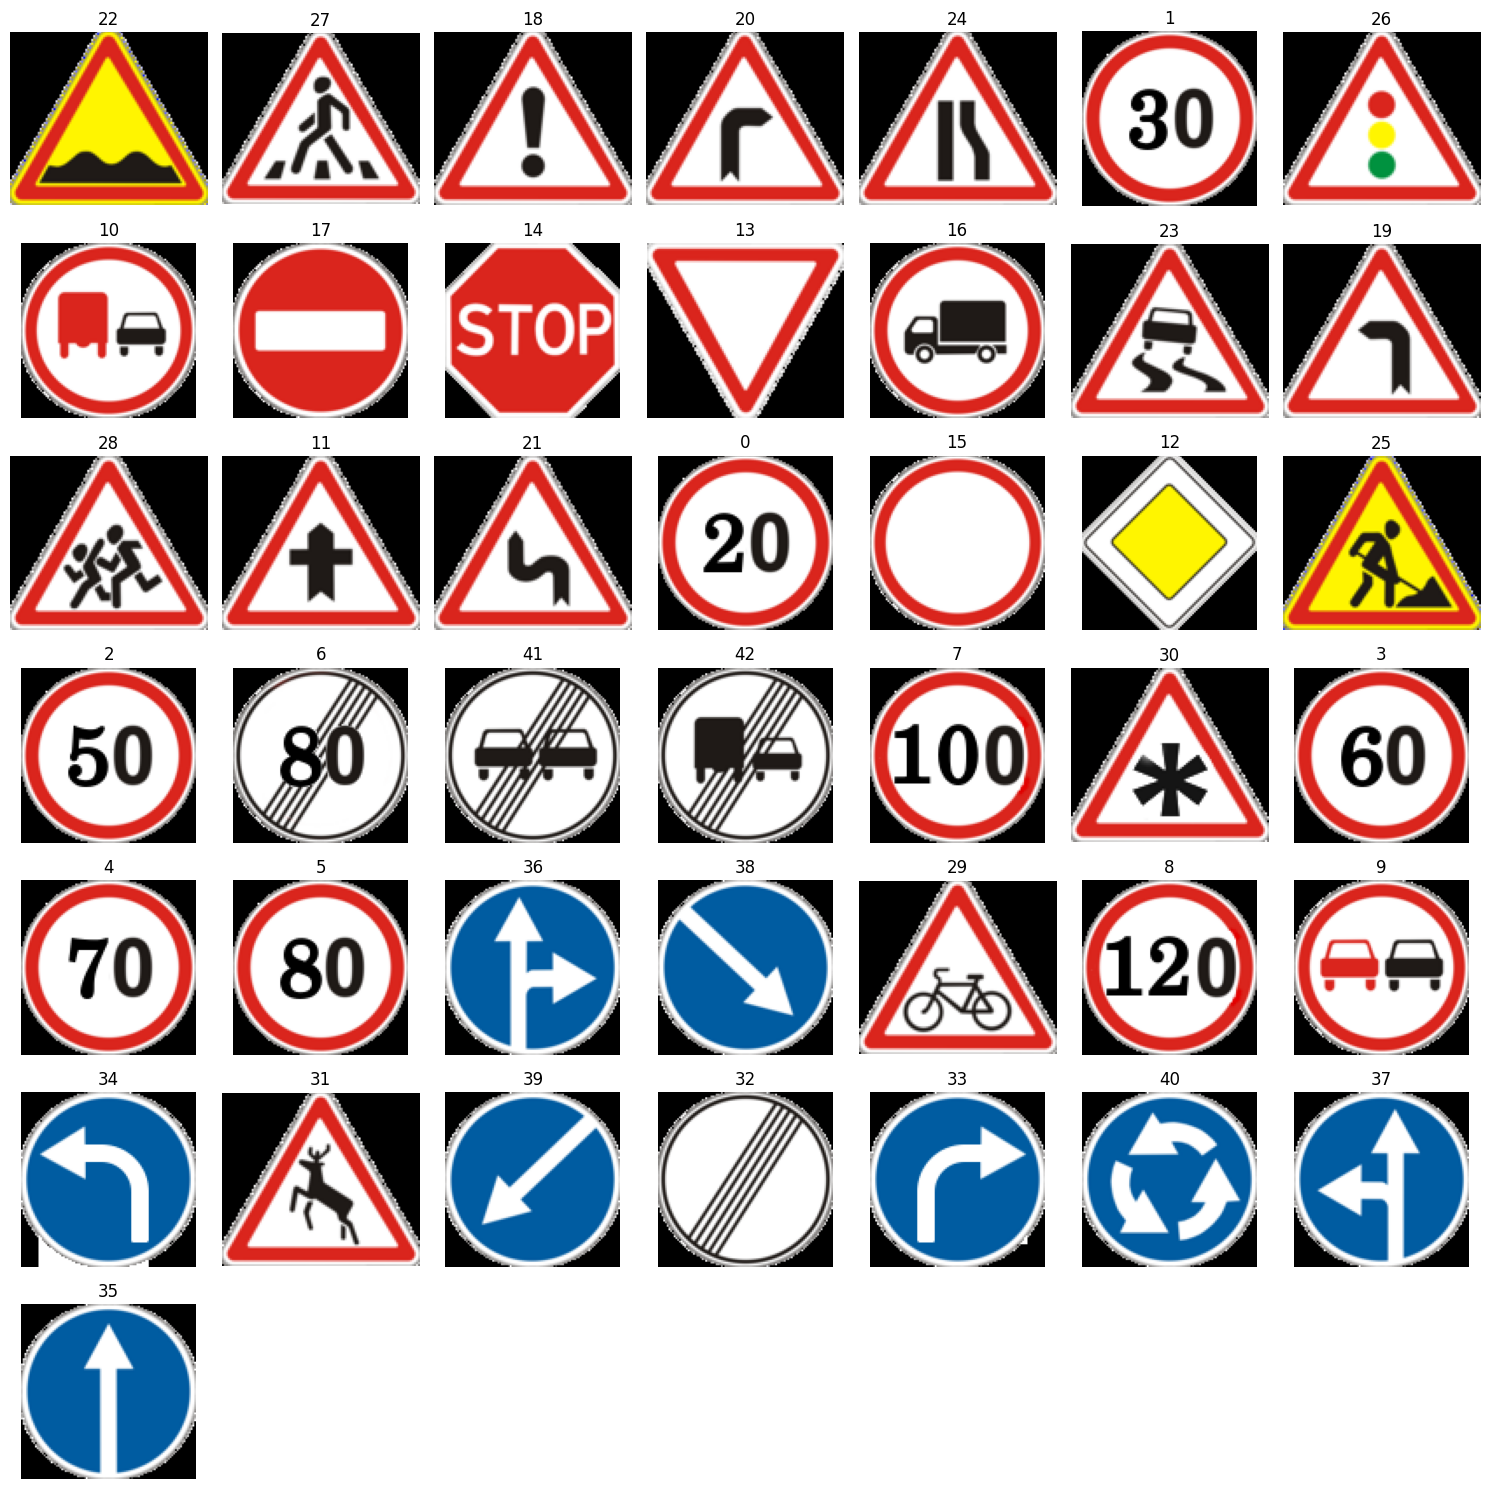

In [ ]:
# Display All Images from Meta Folder

import os
import cv2
import matplotlib.pyplot as plt

meta_path = base_path + "/Meta"

meta_images = os.listdir(meta_path)

plt.figure(figsize=(15,15))

for i, img_name in enumerate(meta_images):

    img_path = os.path.join(meta_path, img_name)

    img = cv2.imread(img_path)
    if img is None:
      print(f"Could not read {img_path}")
      continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(7, 7, i + 1)

    plt.imshow(img)

    plt.title(img_name.split(".")[0])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
Train = pd.read_csv(base_path + "/Train.csv")
Train

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,Train/42/00042_00007_00025.png
39205,56,58,5,5,51,53,42,Train/42/00042_00007_00026.png
39206,58,62,5,6,53,57,42,Train/42/00042_00007_00027.png
39207,63,69,5,7,58,63,42,Train/42/00042_00007_00028.png


In [ ]:
Train.dtypes

,0
Width,int64
Height,int64
Roi.X1,int64
Roi.Y1,int64
Roi.X2,int64
Roi.Y2,int64
ClassId,int64
Path,object


In [ ]:
Train.isna().sum()

,0
Width,0
Height,0
Roi.X1,0
Roi.Y1,0
Roi.X2,0
Roi.Y2,0
ClassId,0
Path,0


In [ ]:
Train.duplicated().sum()

np.int64(0)

In [ ]:
Train.nunique()

,0
Width,187
Height,176
Roi.X1,20
Roi.Y1,16
Roi.X2,177
Roi.Y2,168
ClassId,43
Path,39209


In [ ]:
Test = pd.read_csv(base_path + "/Test.csv")
Test

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png
...,...,...,...,...,...,...,...,...
12625,42,41,5,6,37,36,12,Test/12625.png
12626,50,51,6,5,45,46,33,Test/12626.png
12627,29,29,6,6,24,24,6,Test/12627.png
12628,48,49,5,6,43,44,7,Test/12628.png


In [ ]:
Test.isna().sum()

,0
Width,0
Height,0
Roi.X1,0
Roi.Y1,0
Roi.X2,0
Roi.Y2,0
ClassId,0
Path,0


In [ ]:
Train.duplicated().sum()

np.int64(0)

In [ ]:
Train.nunique()

,0
Width,187
Height,176
Roi.X1,20
Roi.Y1,16
Roi.X2,177
Roi.Y2,168
ClassId,43
Path,39209


**Step 2** Train test split

In [ ]:
#Folder paths

train_path = base_path + "/Train"
test_path = base_path + "/Test"

**Step 3** Load images and Preprocessing(resize)

In [ ]:
# load train images
X_train = []
y_train = []

# Loop through class folders
for class_id in os.listdir(train_path):

    class_folder = os.path.join(train_path, class_id)

    if os.path.isdir(class_folder):

        for img_name in os.listdir(class_folder):

            img_path = os.path.join(class_folder, img_name)

            # Read image
            img = cv2.imread(img_path)

            if img is not None:

                # Resize image
                img = cv2.resize(img, (32,32))

                # Normalize image
                img = img / 255.0

                # Store image
                X_train.append(img)

                # Store label
                y_train.append(int(class_id))

    print(f"Class {class_id} loaded")

Class 16 loaded
Class 14 loaded
Class 1 loaded
Class 17 loaded
Class 18 loaded
Class 10 loaded
Class 11 loaded
Class 13 loaded
Class 12 loaded
Class 15 loaded
Class 21 loaded
Class 19 loaded
Class 20 loaded
Class 2 loaded
Class 22 loaded
Class 0 loaded
Class 23 loaded
Class 30 loaded
Class 29 loaded
Class 25 loaded
Class 32 loaded
Class 26 loaded
Class 27 loaded
Class 28 loaded
Class 34 loaded
Class 3 loaded
Class 31 loaded
Class 33 loaded
Class 35 loaded
Class 24 loaded
Class 38 loaded
Class 39 loaded
Class 36 loaded
Class 4 loaded
Class 37 loaded
Class 41 loaded
Class 40 loaded
Class 42 loaded
Class 5 loaded
Class 6 loaded
Class 8 loaded
Class 9 loaded
Class 7 loaded


In [ ]:
# convert train data to numpy array
X_train = np.array(X_train,dtype='float32')
y_train = np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(39209, 32, 32, 3)
(39209,)


Load test images

In [ ]:
X_test = []

for img_name in os.listdir(test_path):

    img_path = os.path.join(test_path, img_name)

    # Read image
    img = cv2.imread(img_path)

    if img is not None:

        # Resize
        img = cv2.resize(img, (32,32))

        # Normalize
        img = img / 255.0

        X_test.append(img)

print("Test Images Loaded")

Test Images Loaded


In [ ]:
#convert test data to numpy
X_test = np.array(X_test, dtype='float32')

print(X_test.shape)


(12630, 32, 32, 3)


In [ ]:
y_test = Test['ClassId'].values
y_test = to_categorical(y_test, num_classes=43)
y_test.shape

(12630, 43)

One Hot Encoding

In [ ]:
y_train = to_categorical(y_train, num_classes=43)
y_train.shape


(39209, 43)

Data Augmentation(only Train data)

In [ ]:
# Image Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

datagen.fit(X_train)

CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3),
                 activation='relu',
                 input_shape=(32,32,3)))

model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(43, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,459 (642.42 KB)

 Trainable params: 164,459 (642.42 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [ ]:
Traffic = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=100,
    validation_data=(X_test, y_test)
)

Epoch 1/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9747 - loss: 0.0846 - val_accuracy: 0.0386 - val_loss: 47.9140
Epoch 2/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.9758 - loss: 0.0808 - val_accuracy: 0.0386 - val_loss: 49.6550
Epoch 3/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9745 - loss: 0.0841 - val_accuracy: 0.0382 - val_loss: 53.5783
Epoch 4/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.9772 - loss: 0.0775 - val_accuracy: 0.0385 - val_loss: 58.7222
Epoch 5/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.9787 - loss: 0.0717 - val_accuracy: 0.0380 - val_loss: 58.1937
Epoch 6/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.9796 - loss: 0.0668 - val_accuracy: 0.0380 - val_loss: 60.1047
Epoch 7/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.9790 - loss: 0.0701 - val_accuracy: 0.0381 - val_loss: 59.8825
Epoch 8/100
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - acc

Evaluate Model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.05      0.05      0.05       720
           2       0.05      0.05      0.05       750
           3       0.05      0.05      0.05       450
           4       0.05      0.05      0.05       660
           5       0.05      0.05      0.05       630
           6       0.02      0.01      0.01       150
           7       0.04      0.04      0.04       450
           8       0.04      0.04      0.04       450
           9       0.04      0.04      0.04       480
          10       0.06      0.06      0.06       660
          11       0.03      0.04      0.03       420
          12       0.05      0.05      0.05       690
          13       0.06      0.06      0.06       720
          14       0.02      0.02      0.02       270
          15       0.03      0.03      0.03       210
          16       0.01      0.01      0

End to end

# Traffic Signal Recognition CNN Project – Step by Step

## Problem Statement

Build a CNN (Convolutional Neural Network) model that can identify traffic signs from images.

### Dataset Structure

Your dataset contains:

```text
Traffic Sign Recognition for Autonomous Vehicle/
│
├── Train/              # Training images (class folders)
├── Test/               # Test images
├── Meta/               # Sample images for each class
├── Train.csv
├── Test.csv
└── Meta.csv
```

---

# Step 1: Install Required Libraries

```python
!pip install tensorflow pandas numpy matplotlib opencv-python scikit-learn
```

---

# Step 2: Import Libraries

```python
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
```

---

# Step 3: Mount Google Drive (For Colab)

```python
from google.colab import drive
drive.mount('/content/drive')
```

---

# Step 4: Set Dataset Path

## Correct Code

```python
base_path = "/content/drive/MyDrive/Traffic Sign Recognition for Autonomous Vehicle"
```

### Problem Explanation

If the folder name is wrong or missing spaces, Python gives:

```python
FileNotFoundError
```

So always check:

```python
os.listdir('/content/drive/MyDrive')
```

---

# Step 5: Read CSV Files

```python
train_csv = pd.read_csv(base_path + "/Train.csv")
test_csv = pd.read_csv(base_path + "/Test.csv")
meta_csv = pd.read_csv(base_path + "/Meta.csv")
```

---

# Step 6: Check Dataset

```python
print(train_csv.head())
print(test_csv.head())
print(meta_csv.head())
```

```python
print(train_csv.shape)
print(test_csv.shape)
print(meta_csv.shape)
```

---

# Step 7: Handle Missing Values

```python
print(meta_csv.isna().sum())
```

## Correct Fix

```python
meta_csv['SignId'] = meta_csv['SignId'].fillna(0)
```

### Problem Explanation

Missing values (NaN) cause training problems.

`fillna(0)` replaces empty values with 0.

---

# Step 8: Show Sample Meta Image

```python
img_path = base_path + "/Meta/0.png"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()
```

---

# Step 9: Load Training Images

## Correct Code

```python
train_path = base_path + "/Train"

X_train = []
y_train = []

IMG_SIZE = 32

for class_id in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_id)

    if os.path.isdir(class_folder):

        for img_name in os.listdir(class_folder):

            img_path = os.path.join(class_folder, img_name)

            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                X_train.append(img)
                y_train.append(int(class_id))
```

---

# Step 10: Convert into NumPy Arrays

```python
X_train = np.array(X_train, dtype='float32')
y_train = np.array(y_train)

print(X_train.shape)
print(y_train.shape)
```

---

# Step 11: Normalize Images

## Correct Code

```python
X_train = X_train / 255.0
```

### Problem Explanation

Pixel values are from 0 to 255.

Normalization converts them into:

```python
0 to 1
```

This improves CNN performance.

---

# Step 12: Load Test Images

```python
test_path = base_path + "/Test"

X_test = []

for img_name in os.listdir(test_path):

    img_path = os.path.join(test_path, img_name)

    img = cv2.imread(img_path)

    if img is not None:

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X_test.append(img)
```

---

# Step 13: Convert Test Data

```python
X_test = np.array(X_test, dtype='float32')
X_test = X_test / 255.0

print(X_test.shape)
```

---

# Step 14: Create Labels for Test Data

```python
y_test = test_csv['ClassId'].values
```

---

# Step 15: One Hot Encoding

## Correct Code

```python
y_train = to_categorical(y_train, num_classes=43)
y_test = to_categorical(y_test, num_classes=43)
```

### Problem Explanation

CNN classification needs categorical output.

Example:

```python
Class 3 → [0 0 0 1 0 0]
```

---

# Step 16: Data Augmentation

## Correct Code

```python
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False
)
```

### Problem Explanation

Augmentation creates modified images.

Benefits:

* Reduces overfitting
* Improves accuracy
* Makes model robust

---

# Step 17: Build CNN Model

## Correct CNN Model

```python
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(43, activation='softmax'))
```

---

# Step 18: Compile Model

## Correct Code

```python
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
```

---

# Step 19: Model Summary

```python
model.summary()
```

---

# Step 20: Train Model

## Correct Code

```python
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)
```

---

# Step 21: Evaluate Model

```python
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)
```

---

# Step 22: Predictions

```python
y_pred = model.predict(X_test)
```

---

# Step 23: Convert Predictions

```python
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
```

---

# Step 24: Classification Report

```python
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))
```

---

# Step 25: Confusion Matrix

```python
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)
```

---

# Step 26: Save Model

## Correct Code

```python
model.save('traffic_signal_model.h5')
```

---

# Common Errors and Solutions

## 1. FileNotFoundError

### Reason

Wrong dataset path.

### Solution

```python
os.listdir('/content/drive/MyDrive')
```

Check folder name carefully.

---

## 2. OpenCV Error

### Error

```python
cv2.error
```

### Reason

Image not loaded properly.

### Solution

```python
if img is not None:
```

---

## 3. Shape Mismatch Error

### Reason

Images are different sizes.

### Solution

```python
cv2.resize(img, (32,32))
```

---

## 4. Overfitting

### Symptoms

* Train accuracy high
* Validation accuracy low

### Solution

* Use Dropout
* Use Data Augmentation
* Reduce epochs

---

# Final Workflow

```text
Dataset → Preprocessing → Resize → Normalize
→ One Hot Encoding → CNN Model
→ Training → Evaluation → Save Model
```

---

# Expected Accuracy

With proper training:

```text
95% to 99%
```

accuracy is possible.

---

# End Result

Your CNN model can:

* Detect traffic signs
* Classify road symbols
* Help autonomous vehicles
* Be deployed in web or mobile apps
